<!-- reader-content -->

# Differentiability

Differentiate dressed observables and pulse responses, and use JAX gradients
to fit experimental spectroscopy.

## Losses through statics

A scalar loss has a gradient. A vector residual has a Jacobian. Both pass
through the same public `Chip.with_params()` call.

The second observable uses the sigma-z convention
$\chi_{\sigma_z}=\mathrm{dispersive\_shift}/2$. The scalar method returns the
full pull $E_{11}-E_{10}-E_{01}+E_{00}$.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

from quchip import Capacitive, Chip, DuffingTransmon, Resonator

q = DuffingTransmon(freq=5.0, anharmonicity=-0.25, levels=4, label="q")
r = Resonator(freq=7.0, levels=4, label="r")
chip = Chip(
    [q, r],
    [Capacitive(q, r, g=0.05, label="qr")],
    frame="rotating",
    backend="dynamiqs",
)


Define a scalar loss and vector residual. `jax.grad` gives the loss gradient;
`jax.jacrev` gives the observable Jacobian. Sweep the coupling to compare the
resolved curve with its local tangent.

In [2]:
names = ["q.freq", "q.anharmonicity", "qr.g"]
theta = jnp.array([5.0, -0.25, 0.05])
target = jnp.array([5.05, -0.0010])


def observables(th):
    c = chip.with_params(dict(zip(names, th)))
    chi_sigma_z = c.dispersive_shift("q", "r") / 2
    return jnp.stack([jnp.asarray(c.freq("q")), jnp.asarray(chi_sigma_z)])


def residual(th):
    return observables(th) - target


def loss(th):
    return jnp.sum(residual(th) ** 2)


static_gradient = jax.grad(loss)(theta)
static_jacobian = jax.jacrev(residual)(theta)

coupling_values = jnp.linspace(0.02, 0.08, 61)
observable_sweep = jax.vmap(
    lambda coupling: observables(theta.at[2].set(coupling))
)(coupling_values)
coupling_tangent = observables(theta) + (
    coupling_values[:, None] - theta[2]
) * static_jacobian[:, 2]


<details>
<summary>Plotting code</summary>

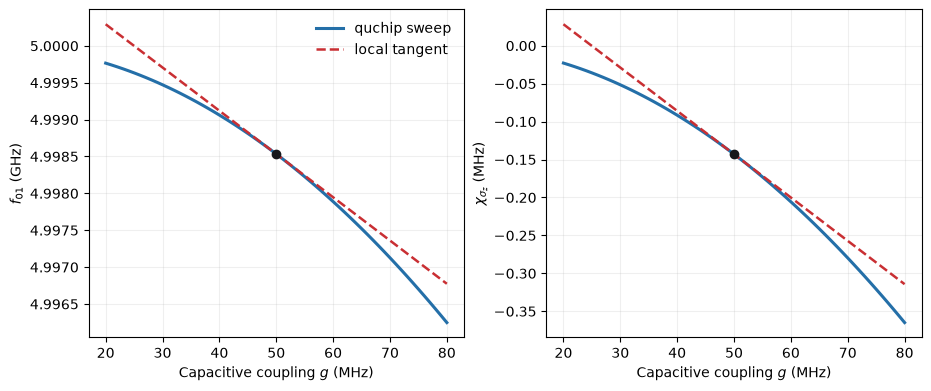

In [3]:
import matplotlib.pyplot as plt

static_figure, static_axes = plt.subplots(1, 2, figsize=(9.2, 3.8), layout="constrained")
for observable_index, (axis, ylabel, scale) in enumerate(
    zip(
        static_axes,
        (r"$f_{01}$ (GHz)", r"$\chi_{\sigma_z}$ (MHz)"),
        (1.0, 1.0e3),
        strict=True,
    )
):
    axis.plot(
        1.0e3 * coupling_values,
        scale * observable_sweep[:, observable_index],
        color="#246FA8",
        linewidth=2.2,
        label="quchip sweep",
    )
    axis.plot(
        1.0e3 * coupling_values,
        scale * coupling_tangent[:, observable_index],
        color="#C92F33",
        linestyle="--",
        linewidth=1.8,
        label="local tangent",
    )
    axis.plot(
        1.0e3 * theta[2],
        scale * observables(theta)[observable_index],
        marker="o",
        color="#16181C",
        linestyle="none",
    )
    axis.set(xlabel=r"Capacitive coupling $g$ (MHz)", ylabel=ylabel)
    axis.grid(alpha=0.2)

static_axes[0].legend(frameon=False)

static_figure_path = "../docs/images/differentiate_static_slope.png"
static_figure.savefig(static_figure_path, dpi=180)
plt.show()

</details>

```{figure} ../images/differentiate_static_slope.png
:width: 760px
:alt: Qubit frequency and dispersive shift swept over capacitive coupling with local tangent lines at 50 megahertz

The black point is where `jax.jacrev` evaluates the slope. The dispersive shift
bends away from its tangent faster than $f_{01}$ over this range.
```

## Fit experimental statics

Stefanski *et al.* fitted a fluxonium spectrum to obtain $E_C$, $E_J$, and
$E_L$. Their [paper](https://arxiv.org/abs/2411.13437) and
[analysis repository](https://github.com/AndersenQubitLab/FPA-RO-experimental)
publish the extracted frequencies and fitted parameters. Here we start away
from those parameters and minimize a differentiable quchip loss.

Every eighth measurement enters the fit. The intervening points remain held
out, and the plotted model uses its own 351-point flux grid.

<details>
<summary>Load the published data and select fit points</summary>

In [4]:
import csv
import io
import json
from urllib.request import urlopen

from scipy.optimize import minimize

from quchip import Fluxonium

paper_data_root = (
    "https://raw.githubusercontent.com/AndersenQubitLab/"
    "FPA-RO-experimental/57dc268dd048d1372db082c3ddd97a04871580bf"
)

with urlopen(f"{paper_data_root}/processed_data_fx8.csv") as response:  # noqa: S310
    spectrum_rows = list(
        csv.DictReader(io.StringIO(response.read().decode("utf-8")))
    )

published_values = np.asarray(
    [float(spectrum_rows[index]["energy_params"]) for index in range(5)]
)
published_energies = published_values[[3, 2, 4]]  # E_C, E_J, E_L

measured_flux_all = np.asarray(
    [float(row["phi_ext_qubit"]) for row in spectrum_rows if row["phi_ext_qubit"]]
)
measured_f01_all = np.asarray(
    [float(row["qubit_freq"]) for row in spectrum_rows if row["qubit_freq"]]
)
paper_window = measured_flux_all <= 0.85
measured_flux = measured_flux_all[paper_window]
measured_f01 = measured_f01_all[paper_window]

training_indices = np.arange(0, measured_flux.size, 8)
holdout_mask = np.ones(measured_flux.size, dtype=bool)
holdout_mask[training_indices] = False
training_flux = jnp.asarray(measured_flux[training_indices])
training_f01 = jnp.asarray(measured_f01[training_indices])

</details>

The optimization model uses a 160-point phase grid. Logarithmic coordinates
keep the three circuit energies positive and put them on comparable numerical
scales.

In [5]:
fit_q = Fluxonium(
    E_C=0.72,
    E_J=4.4,
    E_L=0.68,
    phi_ext=0.5,
    levels=4,
    num_basis=160,
    phi_max=5.0 * np.pi,
    basis="eigen",
    label="q",
)
fit_chip = Chip(
    [fit_q],
    [],
    basis="eigen",
    frame="lab",
    backend="dynamiqs",
)

energy_scale = jnp.asarray([1.0, 4.0, 1.0])
initial_energies = np.asarray([0.72, 4.4, 0.68])
initial_coordinates = jnp.log(jnp.asarray(initial_energies) / energy_scale)


def energies_from_coordinates(coordinates):
    return energy_scale * jnp.exp(coordinates)


def fluxonium_f01(energies, phi_ext):
    point = fit_chip.with_params(
        {
            "q.E_C": energies[0],
            "q.E_J": energies[1],
            "q.E_L": energies[2],
            "q.phi_ext": phi_ext,
        }
    )
    return point.freq("q")


def spectrum_prediction(coordinates, flux):
    energies = energies_from_coordinates(coordinates)
    return jax.vmap(lambda phi: fluxonium_f01(energies, phi))(flux)

Fit a smooth robust loss with SciPy’s bounded optimizer. JAX supplies its
gradient; the loss limits the influence of spectroscopy outliers.

In [6]:
def pseudo_huber(residual):
    return 2.0 * (jnp.sqrt(1.0 + residual**2) - 1.0)


def experimental_loss(coordinates):
    residual_mhz = 1.0e3 * (
        spectrum_prediction(coordinates, training_flux) - training_f01
    )
    return jnp.mean(pseudo_huber(residual_mhz / 3.0))


compiled_loss_and_gradient = jax.jit(jax.value_and_grad(experimental_loss))
loss_history = []


def scipy_objective(coordinates):
    value, gradient = compiled_loss_and_gradient(jnp.asarray(coordinates))
    return float(value), np.asarray(gradient, dtype=float)


fit = minimize(
    scipy_objective,
    np.asarray(initial_coordinates),
    method="L-BFGS-B",
    jac=True,
    bounds=[
        (np.log(0.3), np.log(1.5)),
        (np.log(2.0 / 4.0), np.log(6.0 / 4.0)),
        (np.log(0.3), np.log(1.5)),
    ],
    callback=lambda coordinates: loss_history.append(
        scipy_objective(coordinates)[0]
    ),
    options={"maxiter": 160, "ftol": 1.0e-12, "gtol": 1.0e-9},
)

recovered_energies = np.asarray(
    energies_from_coordinates(jnp.asarray(fit.x)),
    dtype=float,
)

Evaluation starts from a new 351-point model grid. After that forward
calculation, interpolation places the model at the held-out measurement
coordinates for the residual check.

In [7]:
model_flux = jnp.linspace(0.5, 0.85, 351)
model_f01 = np.asarray(spectrum_prediction(jnp.asarray(fit.x), model_flux))
predicted_at_measurements = np.interp(
    measured_flux,
    np.asarray(model_flux),
    model_f01,
)
holdout_residual_mhz = 1.0e3 * (
    predicted_at_measurements[holdout_mask] - measured_f01[holdout_mask]
)


<details>
<summary>Plotting code</summary>

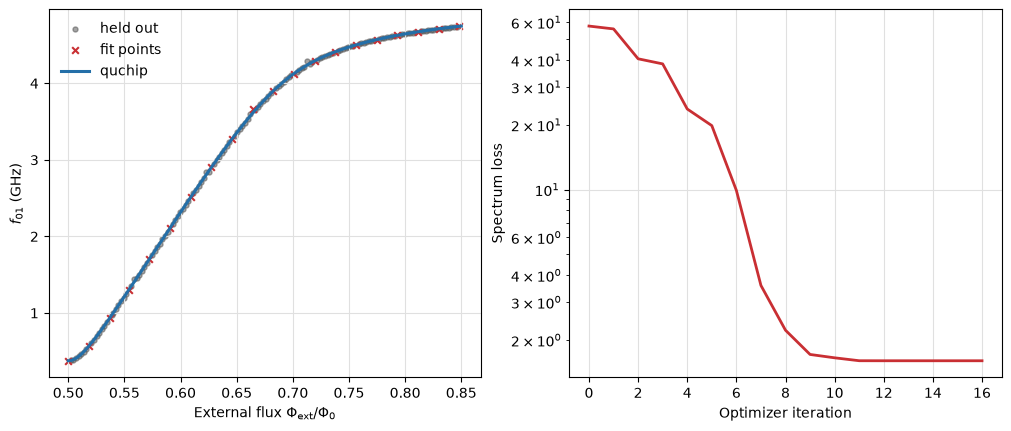

In [8]:
fit_figure, (fit_axis, history_axis) = plt.subplots(
    1,
    2,
    figsize=(10.0, 4.2),
    layout="constrained",
)
fit_axis.scatter(
    measured_flux[holdout_mask],
    measured_f01[holdout_mask],
    s=13,
    color="0.35",
    alpha=0.55,
    label="held out",
)
fit_axis.scatter(
    measured_flux[training_indices],
    measured_f01[training_indices],
    s=23,
    color="#C92F33",
    marker="x",
    label="fit points",
)
fit_axis.plot(model_flux, model_f01, color="#246FA8", linewidth=2.2, label="quchip")
fit_axis.set(
    xlabel=r"External flux $\Phi_{\mathrm{ext}}/\Phi_0$",
    ylabel=r"$f_{01}$ (GHz)",
)
fit_axis.legend(frameon=False)
fit_axis.grid(color="0.88")

history_axis.semilogy(loss_history, color="#C92F33", linewidth=2.0)
history_axis.set(xlabel="Optimizer iteration", ylabel="Spectrum loss")
history_axis.grid(color="0.88")

experimental_fit_path = "../docs/images/differentiate_fluxonium_fit.png"
fit_figure.savefig(experimental_fit_path, dpi=180)
plt.show()

</details>

```{figure} ../images/differentiate_fluxonium_fit.png
:width: 760px
:alt: Fluxonium spectrum fitted on sparse experimental points with held-out measurements and convergence history

Twenty measurements determine the loss. The remaining 133 points test the
recovered spectrum.
```

<details>
<summary>Numerical record</summary>

In [9]:
experimental_fit_receipt = {
    "fit_success": bool(fit.success),
    "iterations": int(fit.nit),
    "training_points": len(training_indices),
    "holdout_points": int(holdout_mask.sum()),
    "published_E_C_E_J_E_L": published_energies.tolist(),
    "initial_E_C_E_J_E_L": initial_energies.tolist(),
    "recovered_E_C_E_J_E_L": recovered_energies.tolist(),
    "relative_parameter_error": (
        (recovered_energies - published_energies) / published_energies
    ).tolist(),
    "holdout_median_absolute_error_mhz": float(
        np.median(np.abs(holdout_residual_mhz))
    ),
    "holdout_rmse_mhz": float(np.sqrt(np.mean(holdout_residual_mhz**2))),
}

print(
    "RESULT experimental_statics="
    + json.dumps(experimental_fit_receipt, sort_keys=True, separators=(",", ":"))
)

RESULT experimental_statics={"fit_success":true,"holdout_median_absolute_error_mhz":0.880613406288866,"holdout_points":133,"holdout_rmse_mhz":6.967105516086398,"initial_E_C_E_J_E_L":[0.72,4.4,0.68],"iterations":17,"published_E_C_E_J_E_L":[0.8652719648666846,3.8217399868188027,0.8215798519627777],"recovered_E_C_E_J_E_L":[0.8704199128839761,3.8203629832283665,0.8208603168362608],"relative_parameter_error":[0.005949514402774777,-0.0003603080259738819,-0.0008757945132148889],"training_points":20}


</details>

The recovered circuit energies are within $0.6\%$ of the authors' values. The
few large spectroscopy residuals remain in the holdout RMSE; the median error
is $0.88$ MHz. This section fits the isolated fluxonium spectrum. The paper's
full fit also included the coupled readout resonator.

## Differentiate a pulse response

This section differentiates the final excited-state population with respect to
pulse amplitude, Gaussian shape, and detuning.

The dynamiqs backend keeps these declared parameters differentiable through
the time-domain solve. Install it with `pip install 'quchip[dynamiqs]'`.

In [10]:
from quchip import RWA, ChargeDrive, Chip, DuffingTransmon, Gaussian, QuantumSequence

amplitude0 = 0.029
frequency0 = 5.0
sigmas0 = 3.0

qubit = DuffingTransmon(
    freq=frequency0,
    anharmonicity=-0.30,
    levels=3,
    label="q",
)
chip = Chip(
    [qubit],
    frame="rotating",
    approximation=RWA(),
    backend="dynamiqs",
)
drive = ChargeDrive(qubit, label="xy")
_ = chip.wire(drive)

sequence = QuantumSequence(chip)
_ = sequence.schedule(
    drive,
    envelope=Gaussian(duration=40.0, sigmas=sigmas0, amplitude=amplitude0),
    freq=frequency0,
)
times = jnp.linspace(0.0, 60.0, 121)
original_parameters = dict(sequence.parameters)

One unit in the perturbation vector means $1\%$ in pulse amplitude, $1\%$ in
the Gaussian parameter $N_\sigma$, or $1$ MHz in pulse detuning. quchip defines
$\sigma=\mathrm{duration}/(2N_\sigma)$, so increasing $N_\sigma$ by $1\%$
narrows the physical Gaussian width by about $1\%$. The derivatives predict
changes in final population on these three scales. `jax.value_and_grad` returns
the population and its derivatives together.

In [11]:
parameter_paths = ("pulse.0.amplitude", "pulse.0.sigmas", "pulse.0.freq")
perturbation_labels = (
    "amplitude (+1%)",
    r"$N_\sigma$ (+1%; $\sigma$ -1%)",
    "detuning (+1 MHz)",
)


def final_population(perturbation):
    rebound = sequence.with_params(
        {
            "pulse.0.amplitude": amplitude0 * (1.0 + 0.01 * perturbation[0]),
            "pulse.0.sigmas": sigmas0 * (1.0 + 0.01 * perturbation[1]),
            "pulse.0.freq": frequency0 + perturbation[2] * 1.0e-3,
        }
    )
    result = rebound.simulate(
        tlist=times,
        initial_state={"q": 0},
        check_truncation=False,
        partition=False,
    )
    return jnp.real(result.population("q", level=1)[-1])
origin = jnp.zeros(3)
population0, gradient = jax.jit(jax.value_and_grad(final_population))(origin)


At this operating point, increasing amplitude or detuning raises the final
population; narrowing the Gaussian lowers it.

<details>
<summary>Plotting code</summary>

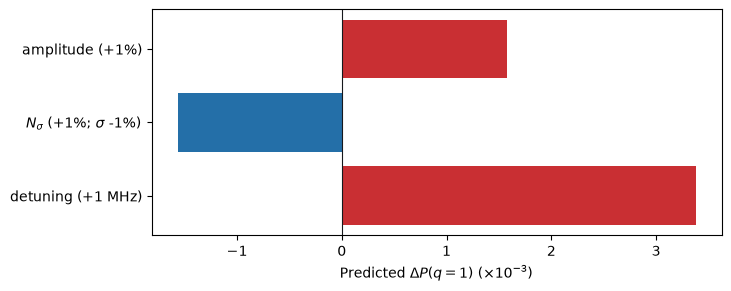

In [12]:
impact = np.asarray(gradient) * 1000
figure, axis = plt.subplots(figsize=(7.2, 2.8), layout="constrained")
axis.barh(perturbation_labels, impact,
          color=["#C92F33" if value >= 0 else "#246FA8" for value in impact])
axis.axvline(0, color="#16181C", lw=0.8)
axis.set(xlabel=r"Predicted $\Delta P(q=1)$ ($\times 10^{-3}$)")
axis.invert_yaxis()
figure_path = "../docs/images/differentiate_a_driven_chip.png"
figure.savefig(figure_path, dpi=180)
plt.show()

</details>

```{figure} ../images/differentiate_a_driven_chip.png
:width: 720px
:alt: Final excited-state population sensitivities to amplitude, pulse width and detuning.

Each bar predicts the population change for the perturbation named on its axis.
```

<details>
<summary>Advanced: share calibration parameters across three experiments</summary>

Combine three pulse experiments with shared qubit frequency, amplitude scale,
and carrier correction. Their durations and nominal detunings stay fixed.

In [13]:
experiment_settings = (
    (18.0, 0.020, -0.004),
    (28.0, 0.026, 0.000),
    (40.0, 0.029, 0.004),
)
experiments = []
for duration, amplitude, carrier_offset in experiment_settings:
    experiment = QuantumSequence(chip)
    experiment.schedule(
        drive,
        envelope=Gaussian(duration=duration, sigmas=3.0, amplitude=amplitude),
        freq=frequency0 + carrier_offset,
    )
    experiments.append(experiment)

shared_names = ("q.freq", "amplitude scale", "carrier correction")
shared_origin = jnp.array([frequency0, 1.0, 0.0])
multi_times = jnp.linspace(0.0, 60.0, 81)

Rebind shared parameters across the three schedules and collect their final populations.

In [14]:
def experiment_outputs(shared):
    qubit_frequency, amplitude_scale, carrier_correction = shared
    values = []
    for experiment, (_, nominal_amplitude, nominal_offset) in zip(
        experiments, experiment_settings
    ):
        rebound = experiment.with_params(
            {
                "q.freq": qubit_frequency,
                "pulse.0.amplitude": nominal_amplitude * amplitude_scale,
                "pulse.0.freq": frequency0 + nominal_offset + carrier_correction,
            }
        )
        result = rebound.simulate(
            tlist=multi_times,
            initial_state={"q": 0},
            check_truncation=False,
            partition=False,
        )
        values.append(jnp.real(result.population("q", level=1)[-1]))
    return jnp.stack(values)

Combine the experiment residuals into one weighted calibration loss.

In [15]:
reference_outputs = experiment_outputs(shared_origin)
multi_targets = jax.lax.stop_gradient(
    reference_outputs + jnp.array([0.010, -0.015, 0.005])
)
experiment_weights = jnp.array([1.0, 2.0, 0.5])


def multi_residual(shared):
    return experiment_outputs(shared) - multi_targets


def multi_loss(shared):
    return jnp.sum(experiment_weights * multi_residual(shared) ** 2)

The Jacobian has one row per experiment and one column per shared parameter.

In [16]:
multi_jacobian = jax.jacrev(multi_residual)(shared_origin)
multi_loss_gradient = jax.grad(multi_loss)(shared_origin)


/private/tmp/quchip-030-installed/lib/python3.11/site-packages/dynamiqs/qarrays/qarray.py:550: UserWarning: A sparse qarray has been converted to dense layout due to element-wise addition with a dense qarray.
  return self + (-y)


/private/tmp/quchip-030-installed/lib/python3.11/site-packages/dynamiqs/qarrays/qarray.py:550: UserWarning: A sparse qarray has been converted to dense layout due to element-wise addition with a dense qarray.
  return self + (-y)


Use the Jacobian to see which experiment constrains each parameter, or the
loss gradient to take an optimization step.

<details>
<summary>Numerical record</summary>

In [17]:
reference_result = sequence.simulate(
    tlist=times,
    initial_state={"q": 0},
    check_truncation=False,
    partition=False,
)

gradient_receipt = {
    "backend": "dynamiqs",
    "base_population": float(population0),
    "figure": figure_path,
    "first_order_only": True,
    "fixed_structure_during_trace": True,
    "gradient_per_reference_perturbation": {
        path: float(value) for path, value in zip(parameter_paths, gradient)
    },
    "multi_sequence_count": len(experiments),
    "multi_sequence_jacobian_shape": list(multi_jacobian.shape),
    "multi_sequence_loss_gradient": [float(value) for value in multi_loss_gradient],
    "original_sequence_unchanged": dict(sequence.parameters) == original_parameters,
    "parameter_paths": list(parameter_paths),
    "solver": reference_result.solver,
}

print(f"RESULT gradient={json.dumps(gradient_receipt, sort_keys=True, separators=(',', ':'))}")

RESULT gradient={"backend":"dynamiqs","base_population":0.995519779566944,"figure":"../docs/images/differentiate_a_driven_chip.png","first_order_only":true,"fixed_structure_during_trace":true,"gradient_per_reference_perturbation":{"pulse.0.amplitude":0.0015756853452387738,"pulse.0.freq":0.00337825563625915,"pulse.0.sigmas":-0.0015669210705104204},"multi_sequence_count":3,"multi_sequence_jacobian_shape":[3,3],"multi_sequence_loss_gradient":[-0.09312824584720562,0.04532470702716049,0.09312824584720582],"original_sequence_unchanged":true,"parameter_paths":["pulse.0.amplitude","pulse.0.sigmas","pulse.0.freq"],"solver":"sesolve"}


</details>

</details>

## Boundaries of this gradient

The traced calculation keeps the device graph, Hilbert-space dimensions, and
RWA band selection fixed. dynamiqs supports this automatic-differentiation
path; QuTiP remains available for ordinary solves and sweeps but does not
provide gradients. Eigenvector derivatives require care near degenerate
subspaces. Gradients inherit the solver tolerances, local-basis
truncation, frame, approximation, and loss scaling chosen for the forward
calculation.